# Regressão Linear - Projeto

Parabéns! Você obteve algum contrato de trabalho com uma empresa de comércio eletrônico com sede na cidade de Nova York que vende roupas online, mas também tem sessões de consultoria em estilo e vestuário na loja. Os clientes entram na loja, têm sessões / reuniões com um estilista pessoal, então podem ir para casa e encomendarem em um aplicativo móvel ou site para a roupa que desejam.

A empresa está tentando decidir se deve concentrar seus esforços em sua experiência em aplicativos móveis ou em seu site. Eles contrataram você no contrato para ajudá-los a descobrir isso! Vamos começar!

Basta seguir as etapas abaixo para analisar os dados do cliente (é falso, não se preocupe, eu não lhe dei números reais de cartões de crédito ou e-mails).

## Imports
** Importe pandas, numpy, matplotlib,e seaborn. Em seguida, configure% matplotlib inline
(Você importará sklearn conforme você precisar). **

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Obter dados

Trabalharemos com o arquivo csv do Ecommerce Customers da empresa. Possui informações do cliente, como Email, Endereço e sua cor Avatar. Em seguida, ele também possui colunas de valores numéricos:.

* Avg. Session Length: Tempo médio das sessões de consultoria de estilo na loja.
* Time on App: tempo médio gasto no app em minutos.
* Time on Website: tempo médio gasto no site em minutos.
* Lenght of Membership: Há quantos anos o cliente é membro.
* Yearly Amount Spent: Valor anual gasto ( Varialve Target no Problema )

** Leia no arquivo csv do Ecommerce Customers como um DataFrame chamado clientes. **

In [2]:
clientes = pd.read_csv("./EcommerceCustomers.csv")

** Verifique o cabeçalho dos clientes e confira os seus métodos info () e describe(). **

In [3]:
clientes.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\r\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\r\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\r\nCobbborough,...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\r\nPort Jason, OH 22070-...",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\r\nPort Jacobville, PR...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [4]:
clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


In [5]:
clientes.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


## Análise de dados exploratória

** Vamos explorar os dados! **

Pelo resto do exercício, só estaremos usando os dados numéricos do arquivo csv.
___
** Use seaborn para criar um jointplot para comparar as colunas Time On Website e Yearly Amount Spent. A correlação faz sentido? **

Text(0.5, 1.05, 'Tempo no Site x Valor Gasto Anualmente')

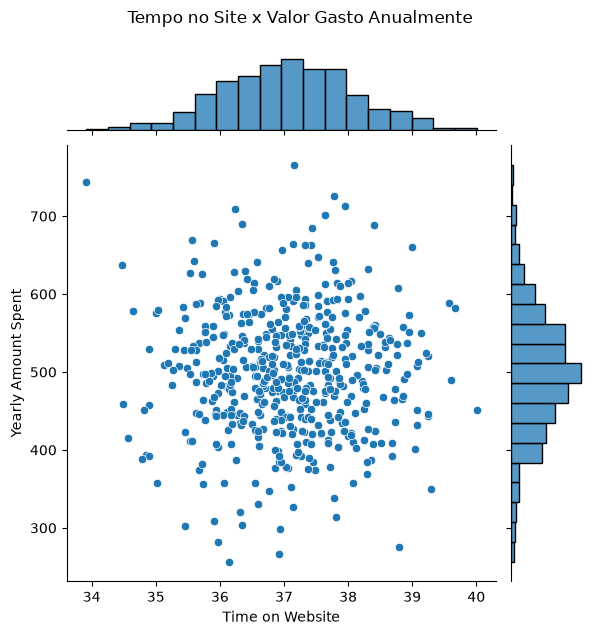

In [6]:
x = sns.jointplot(x = clientes["Time on Website"], y = clientes["Yearly Amount Spent"])
x.figure.suptitle("Tempo no Site x Valor Gasto Anualmente", y=1.05)

** Faça o mesmo, mas com a coluna tempo no aplicativo (Time on App), em vez disso. **

Text(0.5, 1.05, 'Tempo no Aplicativo x Valor Gasto Anualmente')

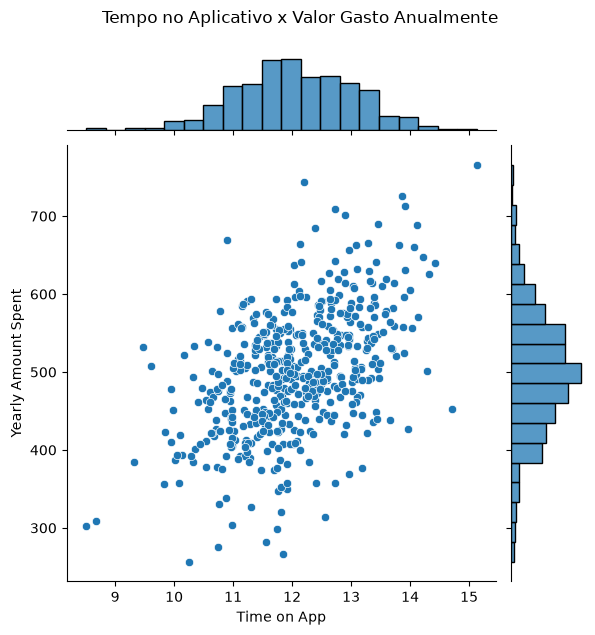

In [7]:
x = sns.jointplot(x = clientes["Time on App"], y = clientes["Yearly Amount Spent"])
x.figure.suptitle("Tempo no Aplicativo x Valor Gasto Anualmente", y=1.05)

** Vamos explorar esses tipos de relações em todo o conjunto de dados. Use [parplot](https://stanford.edu/~mwaskom/software/seaborn/tutorial/axis_grids.html#plotting-pairwise-relationships-with-pairgrid-and-pairplot) para recriar o gráfico abaixo. (Não se preocupe com as cores) **

Text(0.5, 1.05, 'Tempo no Aplicativo x Valor Gasto Anualmente')

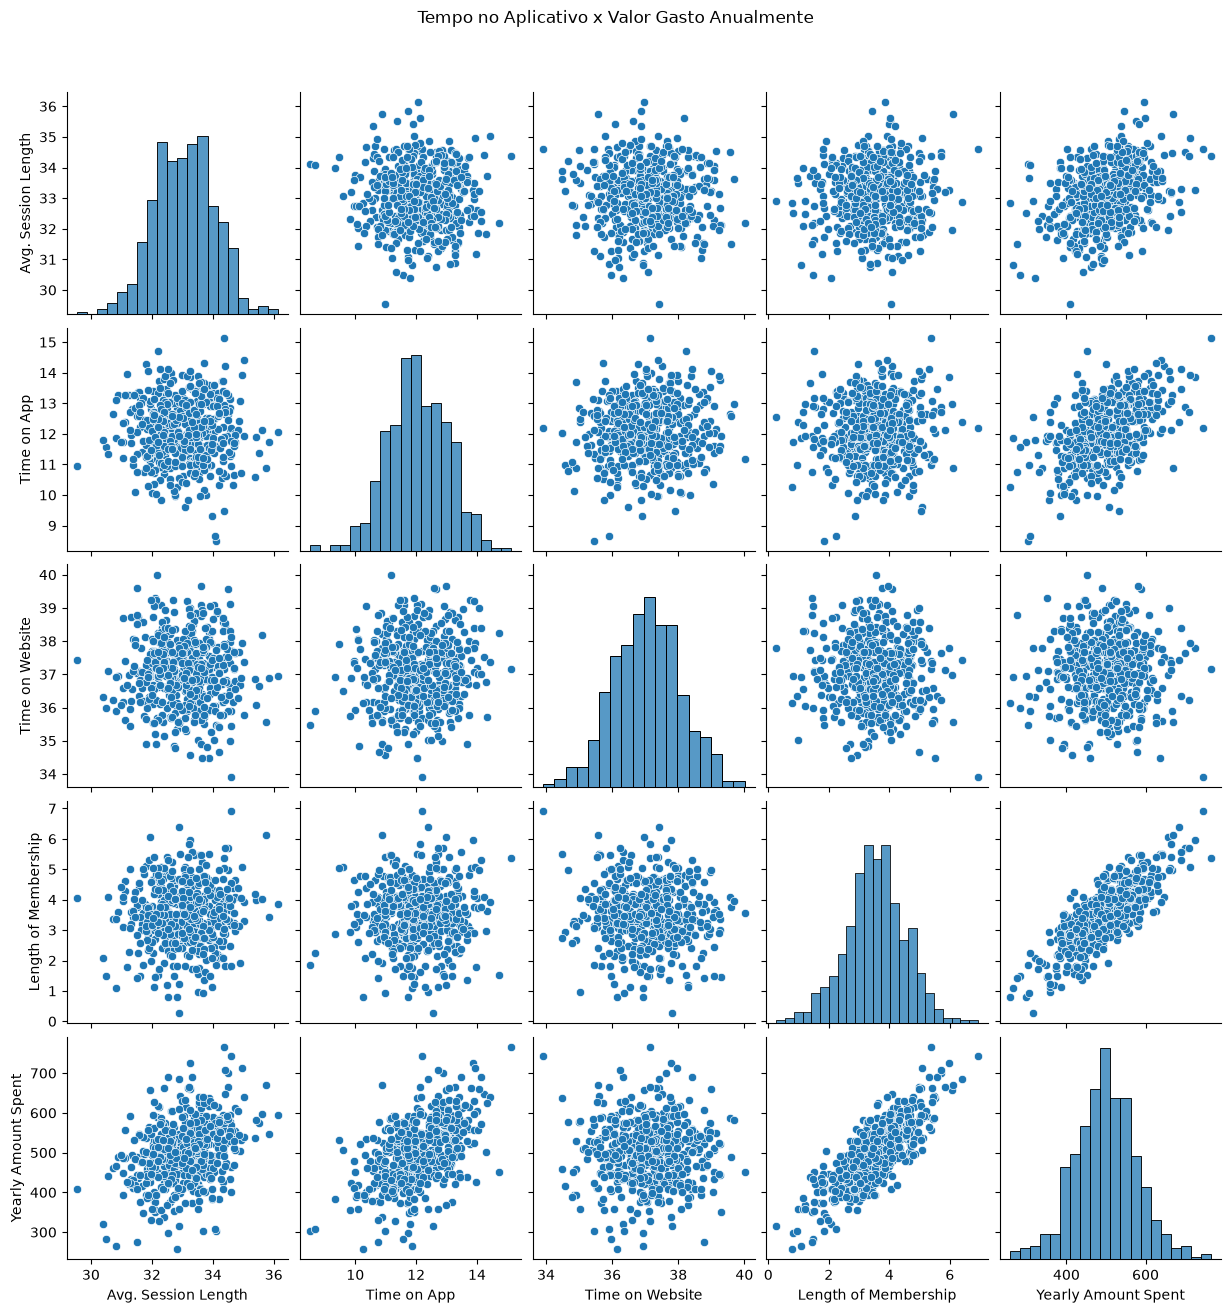

In [8]:
x = sns.pairplot(clientes)
x.figure.suptitle("Tempo no Aplicativo x Valor Gasto Anualmente", y=1.05)

** Crie um plot de um modelo linear (usando o lmplot de Seaborn) da quantia anual gasta (Yearly Amount Spent) vs. tempo de associação (Length of Membership). formato geração grafico: sns.lmplot(x='', y='', data=)**

Text(0.5, 1.05, 'Tempo no Aplicativo x Valor Gasto Anualmente')

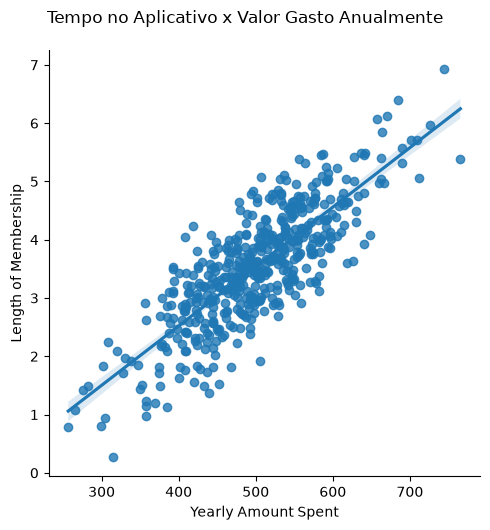

In [9]:
x = sns.lmplot(x="Yearly Amount Spent", y="Length of Membership", data=clientes)
x.figure.suptitle("Tempo no Aplicativo x Valor Gasto Anualmente", y=1.05)

## Analise e Tratamento de Outliers
Agora essa etapa realize analise se tem outliers e faça os devidos tratamentos

In [10]:
clientes.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='str')

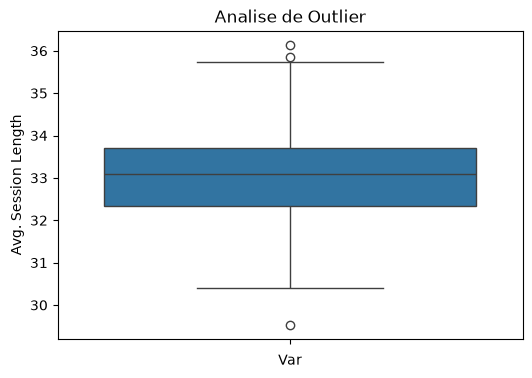

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(clientes["Avg. Session Length"])
plt.title("Analise de Outlier")
plt.xlabel("Var")
plt.show()

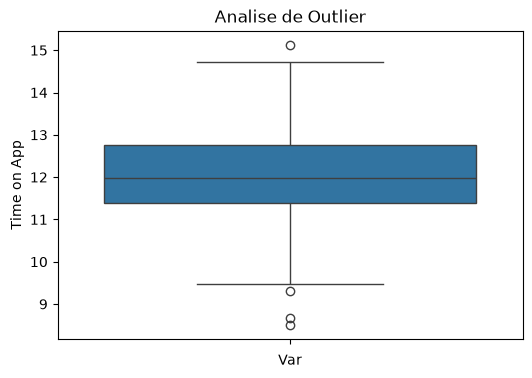

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(clientes["Time on App"])
plt.title("Analise de Outlier")
plt.xlabel("Var")
plt.show()

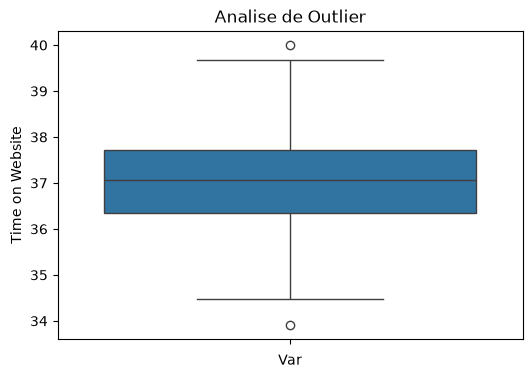

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(clientes["Time on Website"])
plt.title("Analise de Outlier")
plt.xlabel("Var")
plt.show()

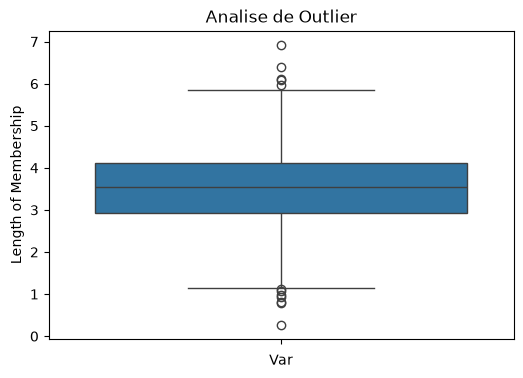

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(clientes["Length of Membership"])
plt.title("Analise de Outlier")
plt.xlabel("Var")
plt.show()

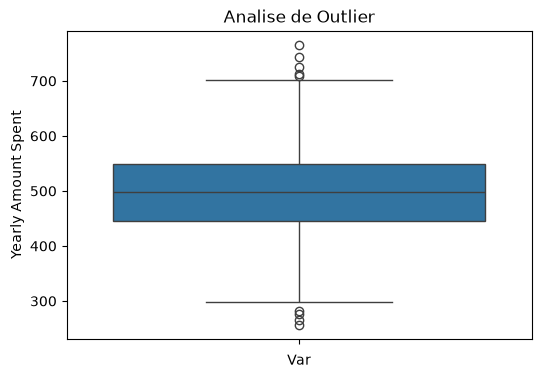

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(clientes["Yearly Amount Spent"])
plt.title("Analise de Outlier")
plt.xlabel("Var")
plt.show()

In [16]:
def substituir_outliers_por_mediana(df, cols=None, ignore_cols=["Email","Address","Avatar"]):
    if cols is None:
        cols = df.select_dtypes(include=["number"]).columns  # apenas numéricas

    # Remove as colunas ignoradas da lista
    cols = [c for c in cols if c not in ignore_cols]

    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mediana = df_clean[col].median()

        # Substitui valores fora do limite
        df_clean.loc[df_clean[col] < lower, col] = mediana
        df_clean.loc[df_clean[col] > upper, col] = mediana
    
    return df_clean

## Treinando e testando os dados

Agora que exploramos um pouco os dados, vamos avançar e dividir os dados em conjuntos de treinamento e teste.
** Defina uma variável X igual a todas as características numéricas dos clientes e uma variável y igual à coluna Valor anual gasto (Yearly Amount Spent). **

In [17]:
clientes_limpo = substituir_outliers_por_mediana(clientes)
clientes_limpo.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.048621,12.065114,37.060885,3.543330,498.818414
std,0.961999,0.951983,0.991901,0.904984,72.975957
min,30.393185,9.477778,34.476878,1.139094,298.762008
25%,32.349308,11.397351,36.354552,2.968870,447.323681
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.705873,12.737178,37.713378,4.104921,547.451353
max,35.742670,14.715388,39.672591,5.840506,700.917092


In [18]:
X = clientes_limpo[["Avg. Session Length", "Time on App", "Time on Website", "Length of Membership"]]
y = clientes_limpo["Yearly Amount Spent"]

** Normalize os dados, utilizando MinMaxScaler() **

In [19]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

** Use model_selection.train_test_split da sklearn para dividir os dados em conjuntos de treinamento e teste. Defina test_size = 0.3 e random_state = 101 **

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=101)

In [21]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (350, 4)
X_test: (150, 4)
y_train: (350,)
y_test: (150,)


## Treinando o modelo

Agora é hora de treinar nosso modelo em nossos dados de treinamento!

** Importe LinearRegression do sklearn.linear_model **

In [22]:
from sklearn.linear_model import LinearRegression

** Crie uma instância de um modelo LinearRegression () chamado lm. **

In [23]:
lm = LinearRegression()

** Treine lm nos dados de treinamento. **

In [24]:
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[119.4 ,190.71, 1.13,279.71]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,203.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[3.62,3.5 ,3.46,3.16]"


**Print os coeficientes do modelo**

In [25]:
coeficientes = pd.DataFrame(lm.coef_, X.columns, columns=["Coeficiente"])
coeficientes

,Coeficiente
Avg. Session Length,119.401414
Time on App,190.714556
Time on Website,1.132090
Length of Membership,279.707097


## Previsão de dados de teste
Agora que nos ajustamos ao nosso modelo, vamos avaliar o seu desempenho ao prever os valores de teste!

** Use lm.predict () para prever o conjunto X_test dos dados. **

In [26]:
predictions = lm.predict(X_test)

## Avaliando o Modelo

Vamos avaliar o desempenho do nosso modelo calculando a soma residual.

** Calcule o erro absoluto médio e o erro quadrado médio **

In [27]:
MAE = mean_absolute_error(y_test, predictions)
MSE = mean_squared_error(y_test, predictions)
RMSE = np.sqrt(MSE)

print("MAE:", MAE)
print("MSE:", MSE)
print("RMSE:", RMSE)

MAE: 15.05315472117594
MSE: 1222.956149234865
RMSE: 34.97078994296333


## Conclusão
Ainda desejamos descobrir a resposta à pergunta original, concentramos-nos no desenvolvimento de aplicativos móveis ou de sites? Ou talvez isso realmente não importe, e o tempo como membro é o que é realmente importante? Vamos ver se podemos interpretar os coeficientes para ter uma idéia.

In [28]:
coeficientes

,Coeficiente
Avg. Session Length,119.401414
Time on App,190.714556
Time on Website,1.132090
Length of Membership,279.707097


Resposta: De acordo com os coeficiêntes de relacionamento, o que mais influência é o tempo que o cliente é membro. Seguido pelo tempo no aplicativo, que é superior ao site, o deixando inútil ao lado do tempo no aplicativo, já que o tempo no site não tem correlação alguma com o valor gasto anualmente do cliente, talvez precisando de alguma melhoria para se tornar tão útil quanto o App.

**Interpretação:**

Olhando para a tabela de coeficientes (lembrando que as variáveis foram normalizadas com o `MinMaxScaler`, então os coeficientes são comparáveis entre si):

- `Length of Membership` tem, de longe, o maior coeficiente (~279.7), ou seja, é a variável que mais influencia o valor gasto anualmente.
- `Time on App` (~190.7) tem um impacto bem maior do que `Time on Website` (~1.1).
- `Avg. Session Length` (~119.4) também tem um efeito relevante.

**Conclusão:** o tempo de site praticamente não afeta o valor gasto pelo cliente, enquanto o tempo no aplicativo tem um impacto bem maior. Isso sugere que a empresa deveria focar seus esforços em melhorar o **aplicativo móvel**. Outra opção seria investigar por que o site tem tão pouco impacto — talvez ele precise de melhorias para se tornar tão eficaz quanto o app. Além disso, o fator mais importante de todos é o **tempo de relacionamento com o cliente** (`Length of Membership`), o que reforça a importância de estratégias de fidelização.